In [1]:
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from typing import TypedDict, List, Annotated, Literal
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
import operator
from pydantic import BaseModel, Field
from langchain_google_genai import ChatGoogleGenerativeAI

In [2]:
load_dotenv()

True

In [3]:
llm = HuggingFaceEndpoint(
    repo_id="Qwen/Qwen3-32B",
    task="text-generation"
)

model = ChatHuggingFace(llm=llm)

/Users/harshraj/Desktop/LangGraph/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
class SentimentSchema(BaseModel):
    sentiment: Literal["positive", "negative"] = Field(description='Sentiment of the review')

In [7]:
class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

In [8]:
model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash"
)
modek = model.with_structured_output(SentimentSchema)
modej = model.with_structured_output(DiagnosisSchema)


In [13]:
class CustomerSupportState(TypedDict):
    review: str
    sentiment: Literal["positive", "negative"]
    diagnosis: str
    response: str

In [40]:
def sentiment_checker(state: CustomerSupportState) -> CustomerSupportState:
    prompt = f"Determine the sentiment of the following customer review and classify it as positive, negative, or neutral:\n\nReview: {state['review']}\n\nSentiment:"
    sentiment = modek.invoke(prompt)
    state['sentiment'] = sentiment
    return {'sentiment': sentiment}


def Diagnostician(state: CustomerSupportState) -> CustomerSupportState:
    prompt = f"Based on the following customer review, provide a diagnosis of the issue:\n\nReview: {state['review']}\n\nDiagnosis:"
    diagnosis = modej.invoke(prompt)
    state['diagnosis'] = diagnosis
    return {'diagnosis': diagnosis}

def NegativeResponseGenerator(state: CustomerSupportState) -> CustomerSupportState:
    prompt = f"Generate a professional and empathetic response to the following negative customer review:\n\nReview: {state['review']}\n\nDiagnosis: {state['diagnosis']}\n\nResponse:"
    response = model.invoke(prompt)
    state['response'] = response
    return {'response': response}

def PositiveResponseGenerator(state: CustomerSupportState) -> CustomerSupportState:
    prompt = f"Generate a professional and appreciative response to the following positive customer review:\n\nReview: {state['review']}Response:"
    response = model.invoke(prompt)
    state['response'] = response
    return {'response': response}

def response_classifier(state: CustomerSupportState) -> Literal["Diagnostic Analysis", "Positive Response Generator"]:
    if state['sentiment'] == 'negative':
        return "Diagnostic Analysis"
    else:
        return "Positive Response Generator"

In [41]:
graph = StateGraph(CustomerSupportState)

graph.add_node("Sentiment Analysis",sentiment_checker)
graph.add_node("Diagnostic Analysis",Diagnostician)
graph.add_node("Negative Response Generator",NegativeResponseGenerator)
graph.add_node("Positive Response Generator",PositiveResponseGenerator)

graph.add_edge(START, "Sentiment Analysis")
graph.add_conditional_edges("Sentiment Analysis", response_classifier)
graph.add_edge("Positive Response Generator", END)
graph.add_edge("Diagnostic Analysis", "Negative Response Generator")
graph.add_edge("Negative Response Generator", END)

workflow = graph.compile()

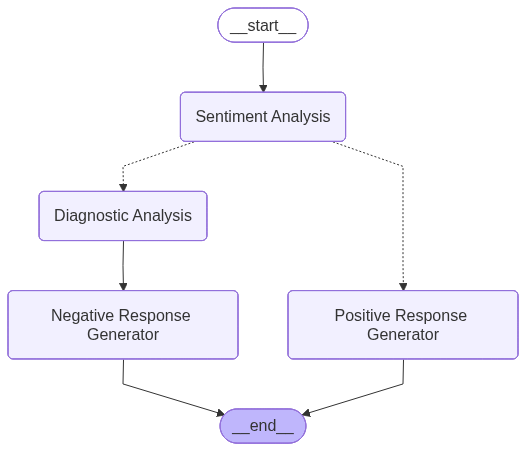

In [42]:
workflow

In [43]:
initial_state={
    'review': "I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality."
}
workflow.invoke(initial_state)

{'review': 'I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality.',
 'sentiment': SentimentSchema(sentiment='negative'),
 'response': AIMessage(content='Subject: We\'re So Sorry You\'re Experiencing Login Issues – Let Us Help!\n\nDear [Customer Name, if available, otherwise "Valued Customer"],\n\nThank you for taking the time to share your feedback, although we are truly sorry to hear about the significant trouble you\'ve experienced trying to log in and the app freezing on the authentication screen.\n\nWe understand how incredibly frustrating it must be to spend over an hour trying to access our app, even after reinstalling it, only to be met with persistent freezing. You are absolutely right – issues affecting basic functionality are unacceptable, and this is certainly not the experience we want for any of our